# Agency Performance Ranking Analysis

## Objective
The objective of this case study is to identify top and bottom performing insurance agencies using a validated business metric and provide insights through data aggregation and visualization.

IMPORTS

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('ggplot')

Load Dataset

In [2]:
df = pd.read_csv("finalapi.csv")

Dataset Overview

In [3]:
print("Rows and Columns:", df.shape)

df.head()

Rows and Columns: (213328, 49)


,AGENCY_ID,PRIMARY_AGENCY_ID,PROD_ABBR,PROD_LINE,STATE_ABBR,STAT_PROFILE_DATE_YEAR,RETENTION_POLY_QTY,POLY_INFORCE_QTY,PREV_POLY_INFORCE_QTY,NB_WRTN_PREM_AMT,...,PL_BOUND_CT_ELINKS,PL_QUO_CT_ELINKS,PL_BOUND_CT_PLRANK,PL_QUO_CT_PLRANK,PL_BOUND_CT_eQTte,PL_QUO_CT_eQTte,PL_BOUND_CT_APPLIED,PL_QUO_CT_APPLIED,PL_BOUND_CT_TRANSACTNOW,PL_QUO_CT_TRANSACTNOW
0,3,3,BOILERMACH,CL,IN,2005,0,0,0,40.0,...,0,0,0,103,50,288,0,0,0,0
1,3,3,BOILERMACH,CL,IN,2006,0,0,0,151.0,...,0,0,0,103,50,288,0,0,0,0
2,3,3,BOILERMACH,CL,IN,2007,0,0,0,40.0,...,0,0,0,103,50,288,0,0,0,0
3,3,3,BOILERMACH,CL,IN,2008,0,0,0,69.0,...,0,0,0,103,50,288,0,0,0,0
4,3,3,BOILERMACH,CL,IN,2009,0,0,0,28.0,...,0,0,0,103,50,288,0,0,0,0


Column Inspection

In [4]:
df.columns.tolist()

['AGENCY_ID',
 'PRIMARY_AGENCY_ID',
 'PROD_ABBR',
 'PROD_LINE',
 'STATE_ABBR',
 'STAT_PROFILE_DATE_YEAR',
 'RETENTION_POLY_QTY',
 'POLY_INFORCE_QTY',
 'PREV_POLY_INFORCE_QTY',
 'NB_WRTN_PREM_AMT',
 'WRTN_PREM_AMT',
 'PREV_WRTN_PREM_AMT',
 'PRD_ERND_PREM_AMT',
 'PRD_INCRD_LOSSES_AMT',
 'MONTHS',
 'RETENTION_RATIO',
 'LOSS_RATIO',
 'LOSS_RATIO_3YR',
 'GROWTH_RATE_3YR',
 'AGENCY_APPOINTMENT_YEAR',
 'ACTIVE_PRODUCERS',
 'MAX_AGE',
 'MIN_AGE',
 'VENDOR_IND',
 'VENDOR',
 'PL_START_YEAR',
 'PL_END_YEAR',
 'COMMISIONS_START_YEAR',
 'COMMISIONS_END_YEAR',
 'CL_START_YEAR',
 'CL_END_YEAR',
 'ACTIVITY_NOTES_START_YEAR',
 'ACTIVITY_NOTES_END_YEAR',
 'CL_BOUND_CT_MDS',
 'CL_QUO_CT_MDS',
 'CL_BOUND_CT_SBZ',
 'CL_QUO_CT_SBZ',
 'CL_BOUND_CT_eQT',
 'CL_QUO_CT_eQT',
 'PL_BOUND_CT_ELINKS',
 'PL_QUO_CT_ELINKS',
 'PL_BOUND_CT_PLRANK',
 'PL_QUO_CT_PLRANK',
 'PL_BOUND_CT_eQTte',
 'PL_QUO_CT_eQTte',
 'PL_BOUND_CT_APPLIED',
 'PL_QUO_CT_APPLIED',
 'PL_BOUND_CT_TRANSACTNOW',
 'PL_QUO_CT_TRANSACTNOW']

Data Cleaning

In [5]:
df.isnull().sum()

AGENCY_ID                    0
PRIMARY_AGENCY_ID            0
PROD_ABBR                    0
PROD_LINE                    0
STATE_ABBR                   0
STAT_PROFILE_DATE_YEAR       0
RETENTION_POLY_QTY           0
POLY_INFORCE_QTY             0
PREV_POLY_INFORCE_QTY        0
NB_WRTN_PREM_AMT             0
WRTN_PREM_AMT                0
PREV_WRTN_PREM_AMT           0
PRD_ERND_PREM_AMT            0
PRD_INCRD_LOSSES_AMT         0
MONTHS                       0
RETENTION_RATIO              0
LOSS_RATIO                   0
LOSS_RATIO_3YR               0
GROWTH_RATE_3YR              0
AGENCY_APPOINTMENT_YEAR      0
ACTIVE_PRODUCERS             0
MAX_AGE                      0
MIN_AGE                      0
VENDOR_IND                   0
VENDOR                       0
PL_START_YEAR                0
PL_END_YEAR                  0
COMMISIONS_START_YEAR        0
COMMISIONS_END_YEAR          0
CL_START_YEAR                0
CL_END_YEAR                  0
ACTIVITY_NOTES_START_YEAR    0
ACTIVITY

In [6]:
df.duplicated().sum()

np.int64(0)

In [16]:
df.drop_duplicates(inplace=True)

## Performance Metric Selection

For agency performance ranking, WRTN_PREM_AMT (Written Premium Amount) is selected because it directly represents the premium revenue generated by an agency and is a suitable indicator of business performance.

Agency + Product Line Aggregation

In [8]:
agency_product = df.groupby(
    ['AGENCY_ID','PROD_LINE']
)['WRTN_PREM_AMT'].agg(
    Total_Premium='sum',
    Average_Premium='mean',
    Record_Count='count'
).reset_index()

agency_product.head()

,AGENCY_ID,PROD_LINE,Total_Premium,Average_Premium,Record_Count
0,3,CL,6147679.46,22113.954892,278
1,3,PL,9824145.84,42163.716052,233
2,11,CL,46582.62,589.653418,79
3,11,PL,35277.24,1469.885000,24
4,12,PL,880554.17,19567.870444,45


Agency Ranking

In [9]:
agency_rank = df.groupby(
    'AGENCY_ID'
)['WRTN_PREM_AMT'].agg(
    Total_Premium='sum',
    Average_Premium='mean',
    Record_Count='count'
).reset_index()

agency_rank = agency_rank.sort_values(
    by='Total_Premium',
    ascending=False
)

agency_rank.head()

,AGENCY_ID,Total_Premium,Average_Premium,Record_Count
873,5468,46079054.07,119997.536641,384
1589,9733,33777988.77,62551.831056,540
288,1786,32761878.06,58818.452531,557
143,886,31047109.86,75357.062767,412
1356,8365,29442920.69,59360.727198,496


Top 10 Agencies

In [10]:
top10 = agency_rank.head(10)

top10

,AGENCY_ID,Total_Premium,Average_Premium,Record_Count
873,5468,46079054.07,119997.536641,384
1589,9733,33777988.77,62551.831056,540
288,1786,32761878.06,58818.452531,557
143,886,31047109.86,75357.062767,412
1356,8365,29442920.69,59360.727198,496
1520,9362,28675251.18,42231.592312,679
716,4351,26006117.63,48700.594813,534
1404,8652,25909071.09,49921.138902,519
1593,9761,25433242.93,75246.280858,338
83,562,25116238.12,60375.572404,416


Bottom 10 Agencies

In [11]:
bottom10 = agency_rank.tail(10)

bottom10

,AGENCY_ID,Total_Premium,Average_Premium,Record_Count
1486,9132,-7.00,-1.400000,5
508,3182,-183.45,-36.690000,5
424,2647,-186.28,-1.981702,94
1104,6810,-228.12,-3.168333,72
499,3103,-397.00,-49.625000,8
16,111,-3602.67,-38.738387,93
165,1054,-5512.16,-76.557778,72
1166,7259,-6862.38,-90.294474,76
217,1400,-23322.58,-485.887083,48
234,1506,-31360.43,-560.007679,56


Top 10 Chart

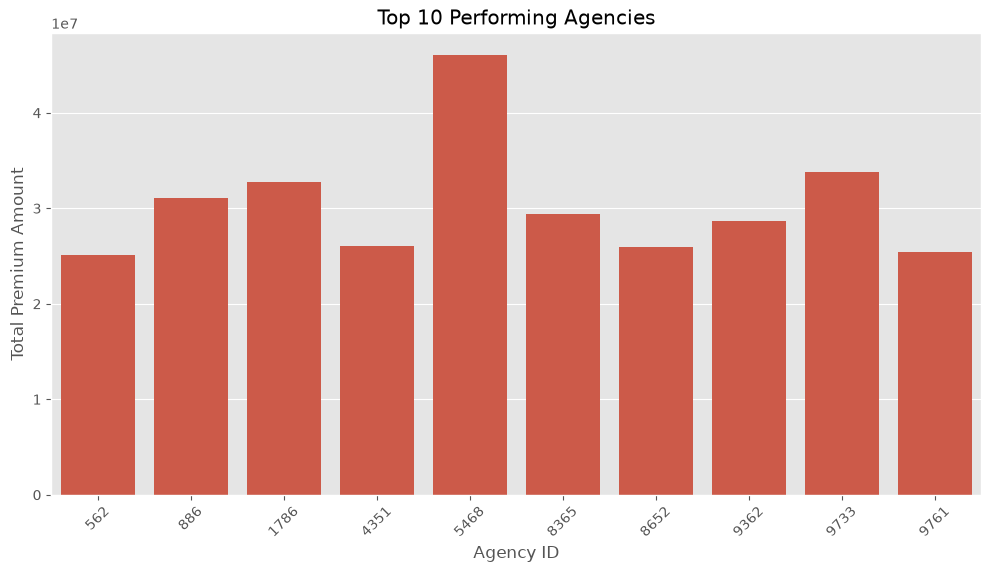

In [12]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=top10,
    x='AGENCY_ID',
    y='Total_Premium'
)

plt.title('Top 10 Performing Agencies')
plt.xlabel('Agency ID')
plt.ylabel('Total Premium Amount')
plt.xticks(rotation=45)

plt.show()

Bottom 10 Chart

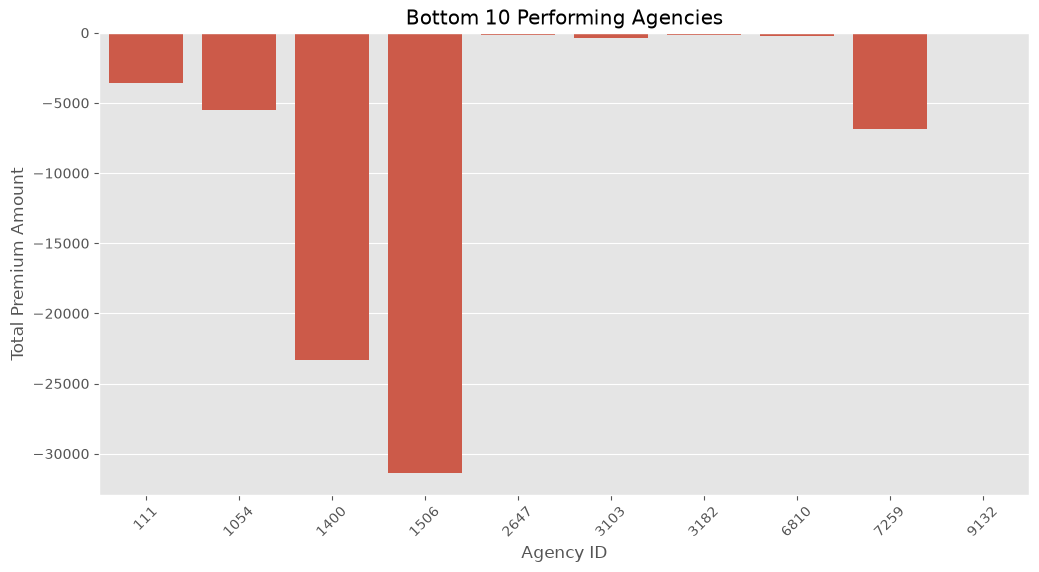

In [13]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=bottom10,
    x='AGENCY_ID',
    y='Total_Premium'
)

plt.title('Bottom 10 Performing Agencies')
plt.xlabel('Agency ID')
plt.ylabel('Total Premium Amount')
plt.xticks(rotation=45)

plt.show()

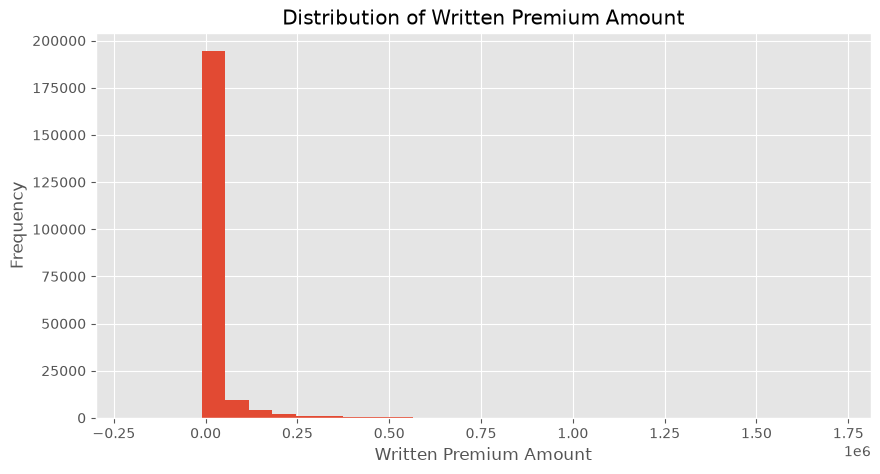

In [14]:
plt.figure(figsize=(10,5))
plt.hist(df['WRTN_PREM_AMT'], bins=30)

plt.title("Distribution of Written Premium Amount")
plt.xlabel("Written Premium Amount")
plt.ylabel("Frequency")

plt.show()

In [15]:
agency_rank.describe()

,AGENCY_ID,Total_Premium,Average_Premium,Record_Count
count,1623.000000,1.623000e+03,1623.000000,1623.000000
mean,5015.470733,2.580531e+06,11630.799451,131.440542
std,2883.533679,4.457071e+06,14635.466631,119.197528
min,3.000000,-3.136043e+04,-560.007679,2.000000
25%,2518.000000,1.673467e+04,641.109130,25.500000
50%,5001.000000,5.710291e+05,6090.766561,107.000000
75%,7592.500000,3.351109e+06,17495.489701,207.000000
max,9998.000000,4.607905e+07,119997.536641,747.000000


## Key Findings

# Key Findings

1. A total of 1,623 agencies were analyzed using Written Premium Amount (WRTN_PREM_AMT).

2. The highest-performing agency generated a Total Premium of approximately 46.08 million, while the lowest-performing agency recorded negative premium values.

3. The average Total Premium across agencies was approximately 2.58 million.

4. The large standard deviation (4.46 million) indicates substantial variation in agency performance.

5. The premium distribution is highly right-skewed, showing that a small number of agencies contribute a large portion of total premium revenue.

6. Negative premium values observed in bottom-performing agencies may indicate policy cancellations, adjustments, or underwriting losses.

## Recommendations

1. Study the business practices and strategies of top-performing agencies.

2. Provide targeted support and performance improvement plans for low-performing agencies.

3. Investigate agencies with negative premium values to identify operational issues.

4. Focus investment and marketing efforts on high-performing product lines and agencies.

5. Continuously monitor agency performance using premium-based metrics and dashboards.

# Conclusion

Agency performance was evaluated using Written Premium Amount (WRTN_PREM_AMT). The analysis identified the top 10 and bottom 10 agencies based on total premium generated. Results indicate significant variation in agency performance, with a small number of agencies contributing a disproportionately large share of premium revenue. The findings suggest that premium amount is an effective metric for measuring agency success and can be used for strategic business decision-making.